# Extended Data Figure 1 — architectural variants and ablations

Redraws the panels of this figure from the released data. Each cell runs a released producer
and shows its output.

Most cells are **level 1**: they redraw a panel from a table shipped in the Zenodo deposit — no
model, no GPU, seconds on a laptop. A few panels have no replot path and need a larger archive,
a checkpoint or a GPU; those cells say so, and `notebooks/README.md` carries the panel-by-panel
table.

Run from the `peint-paper` repository, or set `PEINT_PAPER_REPO` to point at it.

In [1]:
import os, sys, subprocess, pathlib, shutil, tempfile, hashlib
# Locate the peint-paper checkout by looking for its marker files, walking up from the
# working directory. Do NOT resolve a relative ".." here: this cell chdirs to PAPER_REPO
# below, so a relative default would climb one directory on every re-run -- and re-running a
# setup cell is the most ordinary thing anyone does in a notebook. Searching for the marker
# is idempotent: once cwd is the repo root, the root is what the search finds.
def _find_paper_repo():
    env = os.environ.get("PEINT_PAPER_REPO")
    if env:
        return pathlib.Path(env).resolve()
    here = pathlib.Path.cwd().resolve()
    for d in (here, *here.parents):
        if (d / "paper_config.py").exists() and (d / "figures").is_dir():
            return d
    # beside it: this notebook may have been copied somewhere outside the repository, so
    # also look for a checkout hanging off any ancestor
    for d in (here, *here.parents):
        for cand in (d / "repos" / "peint-paper", d / "peint-paper"):
            if (cand / "paper_config.py").exists() and (cand / "figures").is_dir():
                return cand
    raise RuntimeError(
        "Could not find the peint-paper checkout from " + str(here) +
        ". Set PEINT_PAPER_REPO to the repository root, or run this notebook from inside it."
    )

PAPER_REPO = _find_paper_repo()
os.environ.setdefault("PEINT_PAPER_PEINT_REPO", str(PAPER_REPO.parent / "peint"))
os.environ["PEINT_PAPER_LOCAL_DATA_ONLY"] = "1"
os.chdir(PAPER_REPO)
sys.path.insert(0, str(PAPER_REPO))

import pandas as pd, numpy as np
import matplotlib.pyplot as plt

# Inline display needs IPython. These notebooks are also executed headlessly in CI, where it is
# absent, so fall back to printing rather than failing the whole notebook on the import.
try:
    from IPython.display import display, Image
    _INLINE = True
except ImportError:
    _INLINE = False
    def display(x): print(x)
    def Image(filename=None, width=None): return f"[figure written to {filename}]"

# When the current batch of producers started. A cell may call run() several times before a
# single show(); comparing against the LAST run would falsely flag whatever the earlier runs
# wrote. The timestamp is set by the first run() of a batch and cleared by show(), so the
# question asked is "did this panel appear during this cell", not "during the latest command".
#
# The third slot records which cell opened the batch. Without it, a cell that only calls
# show() -- its producer commented out, as in Fig 2c -- compares its panels against the
# PREVIOUS cell's run and reports every one of them as not rewritten.
_last_run = [0.0, False, None]   # [batch start, batch open, cell that opened it]

def _cell_marker():
    """Identify the cell now executing; None when there is no notebook frontend."""
    try:
        from IPython import get_ipython
    except ImportError:
        return None
    ip = get_ipython()
    return getattr(ip, "execution_count", None) if ip is not None else None

def run(module, *args):
    """Run a panel producer and show its output."""
    import time
    cmd = [sys.executable, "-m", module, *args]
    print("$", " ".join(cmd[2:]))
    if not _last_run[1]:
        _last_run[0], _last_run[1], _last_run[2] = time.time(), True, _cell_marker()
    r = subprocess.run(cmd, capture_output=True, text=True)
    tail = [l for l in r.stdout.split("\n") if l.strip()][-15:]
    print("\n".join(tail))
    if r.returncode:
        print(f"\n  *** FAILED (exit {r.returncode}) ***")
        print("  " + r.stderr.strip().split("\n")[-1][:400])
    return r.returncode == 0

_PREVIEW_DIR = pathlib.Path(tempfile.mkdtemp(prefix="peint_panel_preview_"))

def _rasterize(pdf):
    """Render page 1 of a PDF to a PNG so it can be shown inline; None if nothing here can.

    Several panels -- all of Figure 4 -- are only ever written as PDF. The PDF stays the
    artifact of record: this is a throwaway display copy in a scratch dir, redone whenever the
    PDF is newer than it.
    """
    pdf = pathlib.Path(pdf)
    png = _PREVIEW_DIR / (hashlib.md5(str(pdf).encode()).hexdigest()[:10] + ".png")
    if png.exists() and png.stat().st_mtime >= pdf.stat().st_mtime:
        return png
    try:
        import fitz                                   # PyMuPDF, if it happens to be installed
        fitz.open(pdf)[0].get_pixmap(dpi=200).save(png)
        return png
    except Exception:
        pass
    stem = str(png.with_suffix(""))
    for cmd in (["pdftoppm", "-png", "-r", "200", "-singlefile", str(pdf), stem],
                ["pdftocairo", "-png", "-r", "200", "-singlefile", str(pdf), stem],
                ["convert", "-density", "200", str(pdf) + "[0]", "-flatten", str(png)]):
        if not shutil.which(cmd[0]):
            continue
        if subprocess.run(cmd, capture_output=True).returncode == 0 and png.exists():
            return png
    return None

def _show_file(p, w=760, check_stale=True):
    """Show one panel file inline: a PNG as-is, a PDF through a rasterized display copy.

    ``check_stale=False`` is for panels committed to the repository that this notebook cannot
    regenerate (Fig 4a/4b/4d) -- there the mtime says nothing, so the check is waived at the
    call site rather than quietly skipped.
    """
    p = pathlib.Path(p)
    if check_stale and p.stat().st_mtime < _last_run[0]:
        print(f"  NOTE: {p.name} was not rewritten by the command above -- the file on "
              f"disk predates this run. The panel shown below is from an earlier run, so it "
              f"may not correspond to the command just executed.")
    img = p if p.suffix == ".png" else _rasterize(p)
    if img is None:
        print(f"  {p.name} written, but no PDF rasterizer (poppler's pdftoppm, or PyMuPDF) "
              f"is installed to show it inline")
        return
    width = w
    try:                                              # never upscale a small panel to w px
        from PIL import Image as _PILImage
        with _PILImage.open(img) as im:
            width = min(w, im.width)
    except Exception:
        pass
    display(Image(filename=str(img), width=width))

def show(*names, w=760, check_stale=True):
    """Display panel images inline, by name relative to figures/.

    A bare name is looked up in figures/output/ ("figure3_conservation_lg_s256"); a name with a
    subdirectory anywhere under figures/ ("spearman_agg/spearman_plot_esm_150m"). The extension
    is optional -- the PNG is preferred, and a PDF-only panel is rasterized rather than merely
    reported, so every panel can be held up against the printed figure.

    A panel file older than the producer call above it is left over from an earlier run --
    displaying it silently would show you a figure that does not match the code you just ran,
    so say so rather than pretending it is fresh.
    """
    # Only say a panel was not rewritten if a producer ran in THIS cell. A show-only cell has
    # no run of its own to compare against. Where the cell cannot be identified (no IPython,
    # as under scripts/run_notebook.py) fall back to the batch flag, i.e. prior behaviour.
    _marker = _cell_marker()
    ran_here = _last_run[1] if _marker is None else (_last_run[2] == _marker)
    _last_run[1] = False          # close the batch: a later run() starts a new one
    figs = PAPER_REPO / "figures"
    for n in names:
        for p in (figs / f"{n}.png", figs / f"{n}.pdf",
                  figs / "output" / f"{n}.png", figs / "output" / f"{n}.pdf", figs / n):
            if p.exists() and p.suffix in (".png", ".pdf"):
                _show_file(p, w, check_stale and ran_here)
                break
        else:
            print("  not found:", n)

def table(name):
    """Read a released table by name, wherever it lives.

    A producer writes into figures/output; the release ships the same table under
    local_data/figure_data. Look in the released location first so a fresh checkout works
    without having run anything, then fall back to a freshly produced copy.
    """
    for d in (PAPER_REPO / "local_data" / "figure_data",
              PAPER_REPO / "data" / "catjac",
              PAPER_REPO / "figures" / "output"):
        p = d / name
        if p.exists():
            return pd.read_csv(p)
    raise FileNotFoundError(
        f"{name} not found in local_data/figure_data, data/catjac or figures/output. "
        f"Fetch the figure_data tier."
    )


def compare(label, computed, printed, tol=0.05):
    """Print the value this notebook computed beside the one in the manuscript."""
    ok = "MATCH" if abs(computed - printed) <= tol else "CHECK"
    print(f"  {label:<28} computed {computed:>8.3f}   manuscript {printed:>8.3f}   {ok}")

## 1b, 1c — per-site likelihood by transition time and by training step

Level 1. Both panels come out of one released table,
`figure_data/ed1/master_sweep_553fam.csv`: ten variants x fifteen checkpoints x forty-eight
time bins, 7,200 rows. The plotting is the sweep's own `make_report.py`, shipped beside the
table, so these are drawn by the same code that made the published panels rather than a
reimplementation.

Expected at t = 0.1036, step 60k: PEINT (ESMC) 0.6726, LoRA 0.6618, ESM2-150M 0.6603, no
extra encoder layers 0.6587, ESM2-35M 0.6468 and no MLM loss 0.6468, ESM2-8M 0.6416. The
35M / no-MLM tie to four decimals is the overlap the caption points at and resolves in 1c.

The sweep itself is not rerunnable from this release: it spans fifteen checkpoints per
variant and those are not deposited. The table is the reproducible starting point.

$ figures.figure_ed1_ablations


  reading local_data/figure_data/ed1/master_sweep_553fam.csv
  7200 rows: 10 variants x 15 steps (4000-60000) x 48 time bins
  wrote figures/output/ed1b_likelihood_vs_time.{pdf,png}
  wrote figures/output/ed1c_likelihood_vs_step_t0.1.{pdf,png}
  mean per-site likelihood at t = 0.1036, step 60000:
    esmc                 0.6726
    lora                 0.6618
    lora_lr1e-4          0.6608
    baseline             0.6603
    no_encoder_nomask    0.6587
    no_encoder           0.6564
    no_mlm_nomask        0.6468
    esm2_35m             0.6468
    no_mlm               0.6448
    esm2_8m              0.6416


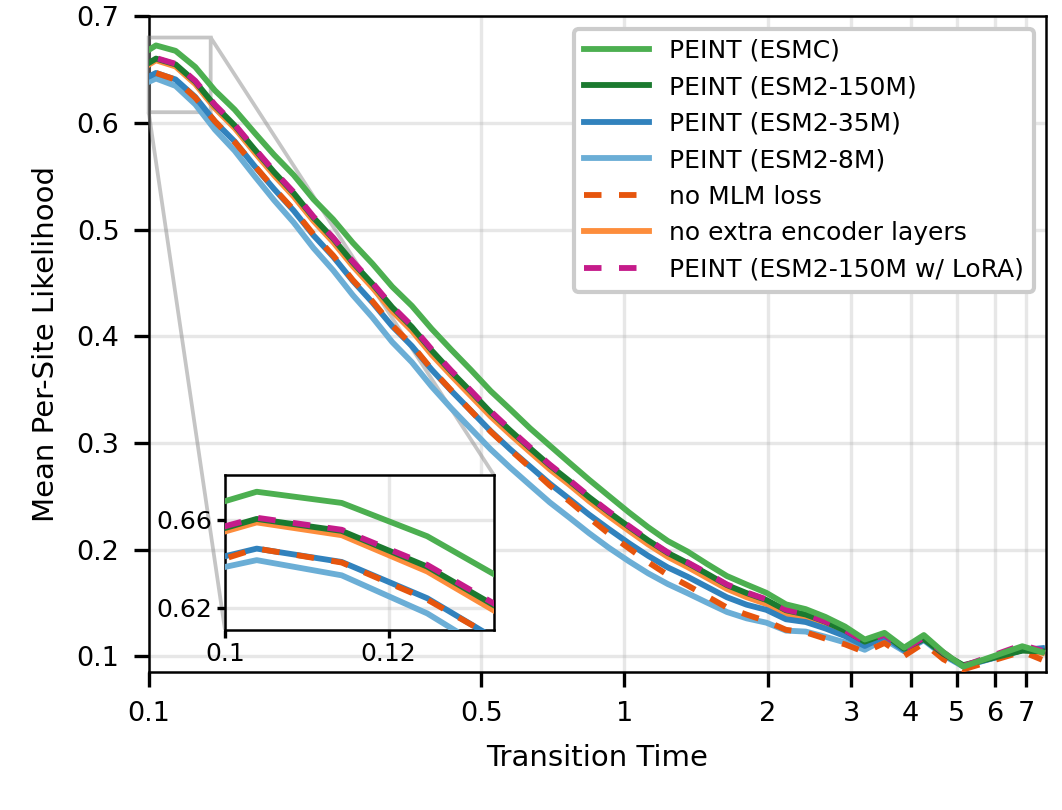

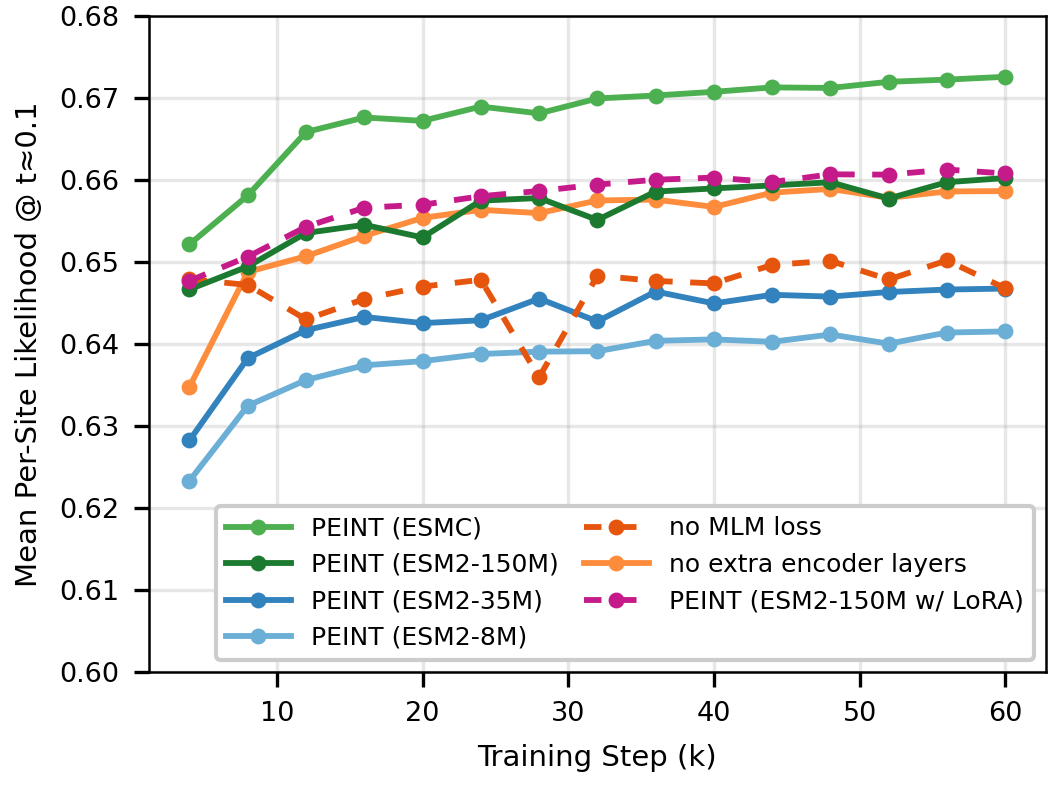

In [2]:
run("figures.figure_ed1_ablations")
show("ed1b_likelihood_vs_time", "ed1c_likelihood_vs_step_t0.1")